In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
%matplotlib inline

In [34]:
df = pd.read_csv('/kaggle/input/healthcare-dataset/healthcare_dataset.csv')
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


* There are 15 Columns And 55500 Rows In The Dataset 

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [36]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [37]:
df.describe(include='O').T

,count,unique,top,freq
Name,55500,49992,DAvId muNoZ,3
Gender,55500,2,Male,27774
Blood Type,55500,8,A-,6969
Medical Condition,55500,6,Arthritis,9308
Date of Admission,55500,1827,2024-03-16,50
Doctor,55500,40341,Michael Smith,27
Hospital,55500,39876,LLC Smith,44
Insurance Provider,55500,5,Cigna,11249
Admission Type,55500,3,Elective,18655
Discharge Date,55500,1856,2020-03-15,53


In [38]:
df.drop_duplicates(inplace= True)

In [39]:
df.isna().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [40]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Duration'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

### Drop Unneeded columns

In [41]:
df.drop(columns=['Name' , 'Date of Admission' ,'Doctor' ,'Insurance Provider' ,'Room Number', 'Discharge Date'] ,
inplace = True , axis = 1)

### Some Data Exploration

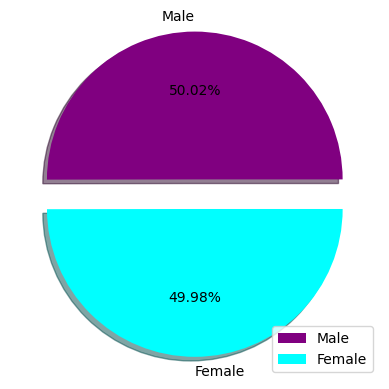

In [43]:
plt.pie(df['Gender'].value_counts(normalize=True)*100 , shadow=True , colors=['purple' , 'cyan'] ,explode=[.1,.1],labels= ['Male' , 'Female'], autopct='%0.2f%%')
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



<Figure size 1200x1000 with 0 Axes>

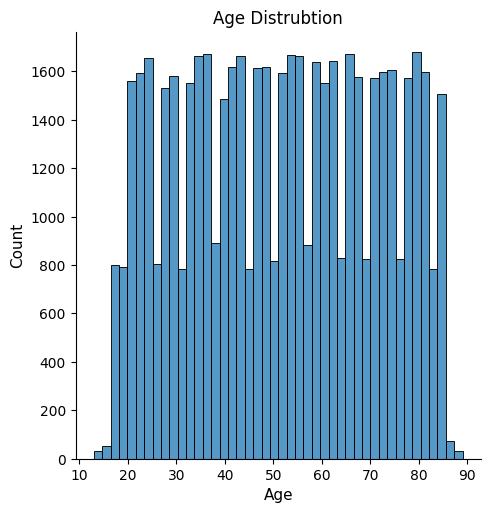

In [44]:
plt.figure(figsize=(12,10))
sns.displot(df['Age'])
plt.title('Age Distrubtion',fontsize=12)
plt.xlabel('Age',fontsize=11)
plt.ylabel('Count',fontsize=11)
plt.show()

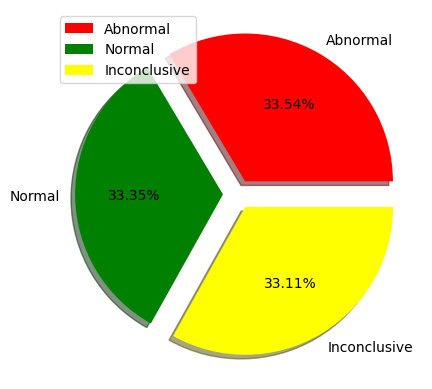

In [45]:
plt.pie(df['Test Results'].value_counts(normalize=True)*100 , shadow=True , colors=['red' , 'green' , 'yellow'] ,explode=[.1,.1,.1],labels= ['Abnormal' , 'Normal' , 'Inconclusive'], autopct='%0.2f%%')
plt.legend(loc='upper left')
plt.show()

In [46]:
Top_10_hospitals = df.groupby('Hospital')['Billing Amount'].sum().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(Top_10_hospitals, x='Billing Amount', y='Hospital', orientation='h', title='Top 10 Hospitals by Billing Amount')
fig.show()

### A full report for every Medical Condition

In [33]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

conditions = ['Arthritis', 'Diabetes', 'Hypertension', 'Obesity', 'Cancer', 'Asthma']

for condition in conditions:
    # Filter data for current condition
    condition_df = df[df['Medical Condition'] == condition]
    
    # Calculate statistics specific to the condition
    avg_age = condition_df['Age'].mean().round(1)
    avg_duration = condition_df['Duration'].mean().round(1)
    
    gender_counts = condition_df['Gender'].value_counts().reset_index()
    gender_counts.columns = ['Gender', 'Count']
    blood_type_counts = condition_df['Blood Type'].value_counts()
    top_hospitals = condition_df.groupby('Hospital')['Billing Amount'].sum().sort_values(ascending=False).head(10).reset_index()
    test_counts = condition_df['Test Results'].value_counts().reset_index()
    test_counts.columns = ['Test Results', 'Count']
    medication_counts = condition_df['Medication'].value_counts()
    admission_counts = condition_df['Admission Type'].value_counts().reset_index()
    admission_counts.columns = ['Admission Type', 'Count']
    
    # Create 3x3 subplot
    fig = make_subplots(
        rows=3, cols=3,
        specs=[
            [{"type": "histogram"}, {"type": "domain"}, {"type": "xy"}],
            [{"type": "histogram"}, {"type": "bar"}, {"type": "domain"}],
            [{"type": "bar"}, {"type": "domain"}, {}]
        ],
        subplot_titles=(
            f"Age Distribution (Avg: {avg_age})", 
            "Gender Distribution",
            "Blood Type Distribution", 
            f"Duration Days Distribution (Avg: {avg_duration})",
            "Top 10 Hospitals by Billing Amount",
            "Test Results Distribution",
            "Medication Distribution",
            "Admission Type Distribution",
            ""
        ),
        horizontal_spacing=0.15,
        vertical_spacing=0.15
    )
    
    # Add plots
    fig.add_trace(px.histogram(condition_df, x='Age', nbins=100, histnorm='percent', 
                              color_discrete_sequence=["#1f55b4"]).data[0], row=1, col=1)
    fig.add_trace(px.sunburst(gender_counts, path=['Gender'], values='Count',
                            color_continuous_scale='Blues').data[0], row=1, col=2)
    fig.add_trace(px.line(x=blood_type_counts.index, y=blood_type_counts.values, 
                         markers=True).data[0], row=1, col=3)
    fig.add_trace(px.histogram(condition_df, x='Duration', nbins=100,
                             color_discrete_sequence=["#1f55b4"]).data[0], row=2, col=1)
    fig.add_trace(px.bar(top_hospitals, x='Billing Amount', y='Hospital', 
                        orientation='h').data[0], row=2, col=2)
    fig.add_trace(px.sunburst(test_counts, path=['Test Results'], values='Count',
                           color_continuous_scale='Blues').data[0], row=2, col=3)
    fig.add_trace(px.bar(medication_counts, x=medication_counts.values, 
                        y=medication_counts.index, orientation='h',
                        labels={'x': 'Medication Count', 'y': 'Medication'},
                        color=medication_counts.values, 
                        color_continuous_scale='Viridis').data[0], row=3, col=1)
    fig.add_trace(px.sunburst(admission_counts, path=['Admission Type'], 
                            values='Count', color_continuous_scale='Blues').data[0], row=3, col=2)
    
    # Attractive background and layout
    fig.update_layout(
        template='plotly',
        paper_bgcolor='rgba(245, 248, 255, 1)',  # soft light blue
        plot_bgcolor='rgba(255, 255, 255, 0.95)',
        height=1600,
        width=1600,
        title_text=f"{condition} Patient Analysis Dashboard",
        title_font_size=28,
        title_font_family='Segoe UI',
        title_font_color='#003366',
        title_x=0.5,
        font=dict(family='Segoe UI', size=15, color='#222'),
        margin=dict(l=50, r=50, t=100, b=120),
        showlegend=False,
        hoverlabel=dict(
            bgcolor="#E6F2FF",
            font_size=13,
            font_family="Segoe UI"
        )
    )
    
    # Axes titles
    fig.update_xaxes(title_text="Age", row=1, col=1)
    fig.update_yaxes(title_text="Percentage", row=1, col=1)
    fig.update_xaxes(title_text="Blood Type", row=1, col=3)
    fig.update_yaxes(title_text="Count", row=1, col=3)
    fig.update_xaxes(title_text="Duration (Days)", row=2, col=1)
    fig.update_yaxes(title_text="Count", row=2, col=1)
    fig.update_xaxes(title_text="Billing Amount", row=2, col=2)
    fig.update_yaxes(title_text="Hospital", row=2, col=2)
    fig.update_xaxes(title_text="Count", row=3, col=1)
    fig.update_yaxes(title_text="Medication", row=3, col=1)
    
    # Annotations with unique content per condition
    fig.add_annotation(
        text=f"<b>{condition} Avg Age: {avg_age}</b>",
        xref="paper", yref="paper",
        x=0.05, y=1.1,
        showarrow=False,
        font=dict(size=13, color="white"),
        bgcolor="#1f77b4",
        bordercolor="#1f77b4",
        borderwidth=1,
        borderpad=6
    )
    
    fig.add_annotation(
        text=f"<b>{condition} Avg Duration: {avg_duration} days</b>",
        xref="paper", yref="paper",
        x=0.7, y=1.1,
        showarrow=False,
        font=dict(size=13, color="white"),
        bgcolor="#1f77b4",
        bordercolor="#1f77b4",
        borderwidth=1,
        borderpad=6
    )

    # Footer
    fig.add_annotation(
        text=f"© 2025 Dashboard for {condition} | Data Source: Hospital Records",
        xref="paper", yref="paper",
        x=0.5, y=-0.07,
        showarrow=False,
        font=dict(size=11, color="gray")
    )
    
    fig.show()
